In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [14]:
df1 = pd.read_csv('car data.csv')
df = df1.copy()
print(df.head())
print(df.info())


  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  3

In [15]:
df['Car_Age'] = 2026 - df['Year']
df['Brand'] = df['Car_Name'].apply(lambda x: x.split()[0])
df.drop(['Car_Name', 'Year'], axis=1, inplace=True)

In [16]:
label_encoder = LabelEncoder()

categorical_cols = ['Fuel_Type', 'Selling_type', 'Transmission', 'Brand']

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

In [17]:
print(df.isnull().sum())
X = df.drop('Selling_Price', axis=1)
y = df['Selling_Price']

Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
Car_Age          0
Brand            0
dtype: int64


In [18]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print('Training data shape:', X_train.shape)
print('Testing data shape:', X_test.shape)

Training data shape: (240, 8)
Testing data shape: (61, 8)


In [19]:
model = LinearRegression()
model.fit(X_train, y_train)




LinearRegression()

In [20]:
y_pred = model.predict(X_test)

print('Predicted Prices:', y_pred[:5])  

Predicted Prices: [ 2.96309199  8.28123095  6.09858334 -1.49102945  9.23736395]


In [21]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R2 Score:', r2)

MAE: 1.226522385270656
MSE: 3.524846556477664
RMSE: 1.877457471283348
R2 Score: 0.8469825433180173


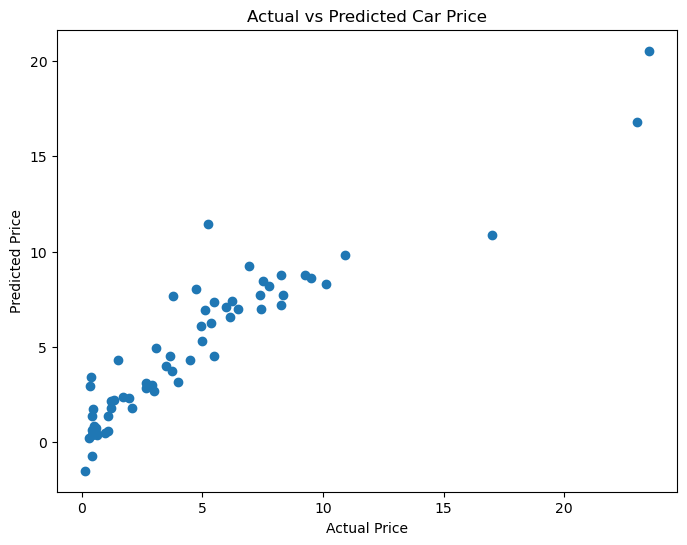

In [22]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Price')
plt.show()